In [3]:
# =============================================================================
# DATA UNDERSTANDING (CRISP-DM) – Dynamic Pricing Mail-Order Pharmacy
# Reproduzierbarer Code-Block: erzeugt ALLE Kennzahlen, Checks und Plots
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# --- Pfade (als Variablen) ---
TRAIN_PATH = "train.csv"
ITEMS_PATH = "items.csv"

print("Libraries loaded.")

Libraries loaded.


In [4]:
# =============================================================================
# 1) COLLECT INITIAL DATA – load_data()
# =============================================================================
def load_data(train_path=TRAIN_PATH, items_path=ITEMS_PATH):
    """Lädt train und items CSV mit pipe-delimiter."""
    train = pd.read_csv(train_path, sep="|", low_memory=False)
    items = pd.read_csv(items_path, sep="|", low_memory=False)
    return train, items

train, items = load_data()

print("=" * 60)
print("SECTION 1 – COLLECT INITIAL DATA")
print("=" * 60)
print(f"\ntrain shape: {train.shape}")
print(f"items shape: {items.shape}")
print(f"\ntrain dtypes:\n{train.dtypes}")
print(f"\nitems dtypes:\n{items.dtypes}")
print(f"\ntrain.head():\n{train.head().to_string()}")
print(f"\nitems.head():\n{items.head().to_string()}")

SECTION 1 – COLLECT INITIAL DATA

train shape: (2756003, 11)
items shape: (22035, 11)

train dtypes:
lineID               int64
day                  int64
pid                  int64
adFlag               int64
availability         int64
competitorPrice    float64
click                int64
basket               int64
order                int64
price              float64
revenue            float64
dtype: object

items dtypes:
pid                 int64
manufacturer        int64
group              object
content            object
unit               object
pharmForm          object
genericProduct      int64
salesIndex          int64
category          float64
campaignIndex      object
rrp               float64
dtype: object

train.head():
   lineID  day    pid  adFlag  availability  competitorPrice  click  basket  order  price  revenue
0       1    1   6570       0             2            14.60      1       0      0  16.89     0.00
1       2    1  14922       1             1             8.57

In [5]:
# =============================================================================
# 2) DESCRIBE DATA – describe_data()
# =============================================================================
def describe_data(train, items):
    """Berechnet Sizes, Missing, Konzentration, Aktionsverteilung und
    führt Integrity Checks durch."""
    
    print("=" * 60)
    print("SECTION 2 – DESCRIBE DATA")
    print("=" * 60)
    
    # --- 2.1 Sizes ---
    print("\n--- 2.1 Sizes ---")
    print(f"train: {train.shape[0]:,} rows × {train.shape[1]} cols")
    print(f"items: {items.shape[0]:,} rows × {items.shape[1]} cols")
    
    n_unique_pid_train = train["pid"].nunique()
    n_unique_pid_items = items["pid"].nunique()
    n_items_rows = len(items)
    n_unique_days = train["day"].nunique()
    day_range = (train["day"].min(), train["day"].max())
    
    print(f"\nUnique PIDs in train: {n_unique_pid_train:,}")
    print(f"Unique PIDs in items: {n_unique_pid_items:,}")
    print(f"Total rows in items:  {n_items_rows:,}")
    
    # Duplikat-Check items.pid
    items_pid_dupes = n_items_rows - n_unique_pid_items
    if items_pid_dupes > 0:
        print(f"⚠ WARNUNG: items.pid hat {items_pid_dupes} Duplikate! "
              "Dimensionstabelle ist NICHT sauber.")
    else:
        print("✓ items.pid ist eindeutig (keine Duplikate).")
    
    print(f"\nUnique Days: {n_unique_days} (day {day_range[0]}–{day_range[1]})")
    
    # Orphan-Analyse
    pids_train = set(train["pid"].unique())
    pids_items = set(items["pid"].unique())
    orphan_train = pids_train - pids_items  # PIDs in train aber nicht in items
    orphan_items = pids_items - pids_train  # PIDs in items aber nicht in train
    
    print(f"\nOrphan PIDs in train (nicht in items): {len(orphan_train)}")
    if len(orphan_train) > 0:
        print(f"  ⚠ Dies ist ein Datenqualitätsproblem! PIDs: {list(orphan_train)[:10]}...")
    else:
        print("  ✓ Alle train PIDs existieren in items.")
    
    print(f"Orphan PIDs in items (keine Events in train): {len(orphan_items)}")
    print(f"  → Produkte im Katalog ohne Aktivität im Beobachtungszeitraum (erwartet, kein Fehler).")
    
    # Merge
    df = pd.merge(train, items, on="pid", how="left")
    print(f"\nMerged DataFrame: {df.shape[0]:,} rows × {df.shape[1]} cols")
    
    # --- 2.2 Events per PID ---
    print("\n--- 2.2 Events per PID ---")
    events_per_pid = train.groupby("pid")["lineID"].count().sort_values(ascending=False)
    print(events_per_pid.describe(percentiles=[.5, .9, .99]).to_string())
    
    # Konzentration
    n_pids = len(events_per_pid)
    share_top_1  = events_per_pid.head(int(0.01 * n_pids)).sum() / len(train)
    share_top_10 = events_per_pid.head(int(0.10 * n_pids)).sum() / len(train)
    share_bot_50 = events_per_pid.tail(int(0.50 * n_pids)).sum() / len(train)
    
    print(f"\nKonzentration:")
    print(f"  Top  1% PIDs: {share_top_1:.2%} aller Events")
    print(f"  Top 10% PIDs: {share_top_10:.2%} aller Events")
    print(f"  Bot 50% PIDs: {share_bot_50:.2%} aller Events")
    
    # --- Aktionsverteilung (Action Distribution) ---
    print("\n--- Aktionsverteilung ---")
    action_counts = train[["click", "basket", "order"]].sum()
    action_rates  = action_counts / len(train)
    action_df = pd.DataFrame({
        "Count": action_counts,
        "Rate": action_rates
    })
    print(action_df.to_string())
    
    # --- 2.3 Missing Values ---
    print("\n--- 2.3 Fehlende Werte (train) ---")
    miss_train = train.isnull().sum()
    miss_train_pct = (miss_train / len(train) * 100).round(2)
    miss_df_train = pd.DataFrame({"Missing": miss_train, "Missing%": miss_train_pct})
    print(miss_df_train[miss_df_train["Missing"] > 0].to_string() 
          if miss_df_train["Missing"].sum() > 0 
          else "  Keine Missing Values in train.")
    
    print("\n--- Fehlende Werte (items) ---")
    miss_items = items.isnull().sum()
    miss_items_pct = (miss_items / len(items) * 100).round(2)
    miss_df_items = pd.DataFrame({"Missing": miss_items, "Missing%": miss_items_pct})
    print(miss_df_items[miss_df_items["Missing"] > 0].to_string()
          if miss_df_items["Missing"].sum() > 0
          else "  Keine Missing Values in items.")
    
    print("\n--- Fehlende Werte (zusammengeführt) ---")
    miss_merged = df.isnull().sum()
    miss_merged_pct = (miss_merged / len(df) * 100).round(2)
    miss_df_merged = pd.DataFrame({"Missing": miss_merged, "Missing%": miss_merged_pct})
    print(miss_df_merged[miss_df_merged["Missing"] > 0].to_string()
          if miss_df_merged["Missing"].sum() > 0
          else "  Keine Missing Values in der zusammengeführten Tabelle.")
    
    return df, events_per_pid

df, events_per_pid = describe_data(train, items)

SECTION 2 – DESCRIBE DATA

--- 2.1 Sizes ---
train: 2,756,003 rows × 11 cols
items: 22,035 rows × 11 cols

Unique PIDs in train: 21,928
Unique PIDs in items: 22,035
Total rows in items:  22,035
✓ items.pid ist eindeutig (keine Duplikate).

Unique Days: 92 (day 1–92)

Orphan PIDs in train (nicht in items): 0
  ✓ Alle train PIDs existieren in items.
Orphan PIDs in items (keine Events in train): 107
  → Produkte im Katalog ohne Aktivität im Beobachtungszeitraum (erwartet, kein Fehler).

Merged DataFrame: 2,756,003 rows × 21 cols

--- 2.2 Events per PID ---
count    21928.000000
mean       125.684194
std        529.278123
min          1.000000
50%         32.000000
90%        260.000000
99%       1506.000000
max      53785.000000

Konzentration:
  Top  1% PIDs: 25.63% aller Events
  Top 10% PIDs: 64.74% aller Events
  Bot 50% PIDs: 5.34% aller Events

--- Aktionsverteilung ---
          Count      Rate
click   1582827  0.574320
basket   468086  0.169842
order    705090  0.255838

--- 2.3 F

In [6]:
# =============================================================================
# 2.3) SANITY CHECKS – sanity_checks()
# =============================================================================
def sanity_checks(train, items):
    """Führt alle Integrity Checks durch und gibt PASS/FAIL aus."""
    
    print("=" * 60)
    print("SECTION 2.3 – INTEGRITY / SANITY CHECKS")
    print("=" * 60)
    results = {}
    
    # 1) Action Exclusivity: click + basket + order == 1
    action_sum = train["click"] + train["basket"] + train["order"]
    violations_action = (action_sum != 1).sum()
    results["Aktionen halten die Bedingung (click+basket+order==1)"] = violations_action
    
    # 2) Price > 0
    violations_price = (train["price"] <= 0).sum()
    results["Preis > 0"] = violations_price
    
    # 3) CompetitorPrice > 0 (wo vorhanden)
    comp_mask = train["competitorPrice"].notna()
    violations_comp = (train.loc[comp_mask, "competitorPrice"] <= 0).sum()
    results["CompetitorPrice > 0 (wo vorhanden)"] = violations_comp
    
    # 4) Revenue >= 0 und Revenue > 0 wenn order==1 und wenn order==0 (kein negativer Umsatz, und bei Bestellungen muss Umsatz = 0 sein)
    violations_rev = (train["revenue"] < 0).sum()
    results["Revenue >= 0"] = violations_rev
    violations_rev_order = ((train["order"] == 1) & (train["revenue"] <= 0)).sum()
    results["Revenue > 0 wenn order==1"] = violations_rev_order
    violations_rev_no_order = ((train["order"] == 0) & (train["revenue"] != 0)).sum()
    results["Revenue = 0 wenn order==0 (violations)"] = violations_rev_no_order
    
    # 5) lineID unique
    violations_lineid = train["lineID"].duplicated().sum()
    results["lineID unique (keine Duplikate)"] = violations_lineid
    
    # 6) items.pid unique
    violations_items_pid = items["pid"].duplicated().sum()
    results["items.pid unique (keine Duplikate)"] = violations_items_pid
    
    # 7) No orphan train PIDs
    orphan_train_count = len(set(train["pid"]) - set(items["pid"]))
    results["No orphan train PIDs"] = orphan_train_count
    
    # Print results
    print()
    all_pass = True
    for check_name, violation_count in results.items():
        status = "✓ PASS" if violation_count == 0 else f"✗ FAIL ({violation_count:,} violations)"
        if violation_count > 0:
            all_pass = False
        print(f"  {status} – {check_name}")
    
    # 8) Orphan items (informational, not a failure)
    orphan_items_count = len(set(items["pid"]) - set(train["pid"]))
    print(f"\n  ℹ Orphan items (PIDs in items ohne Events): {orphan_items_count}")
    
    print(f"\n{'='*60}")
    print(f"OVERALL: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED – investigate!'}")
    print(f"{'='*60}")
    
    return results

check_results = sanity_checks(train, items)

SECTION 2.3 – INTEGRITY / SANITY CHECKS

  ✓ PASS – Aktionen halten die Bedingung (click+basket+order==1)
  ✓ PASS – Preis > 0
  ✗ FAIL (976 violations) – CompetitorPrice > 0 (wo vorhanden)
  ✓ PASS – Revenue >= 0
  ✓ PASS – Revenue > 0 wenn order==1
  ✓ PASS – Revenue = 0 wenn order==0 (violations)
  ✓ PASS – lineID unique (keine Duplikate)
  ✓ PASS – items.pid unique (keine Duplikate)
  ✓ PASS – No orphan train PIDs

  ℹ Orphan items (PIDs in items ohne Events): 107

OVERALL: SOME CHECKS FAILED – investigate!


In [12]:
def leakage_audit(train, threshold=0.01, accept_rate=0.95):
   
    print("\n" + "="*60)
    print("SECTION 3.1 – TARGET DEFINITION")
    print("="*60)

    # -----------------------
    # Umsatz Check
    # -----------------------
    print("\nUmsatz Check")
    rev_pos_without_order = ((train["revenue"] > 0) & (train["order"] != 1)).sum()
    rev_zero_with_order  = ((train["order"] == 1) & (train["revenue"] <= 0)).sum()
    total_orders         = (train["order"] == 1).sum()

    print(f"Orders total (order==1): {total_orders:,}")
    print(f"Violations: revenue>0 but order!=1: {rev_pos_without_order:,}")
    print(f"Violations: order==1 but revenue<=0: {rev_zero_with_order:,}")

    # -----------------------
    # Mengenabweichungen Check
    # -----------------------
    print("\nMengenabweichungen (Menge = revenue/price)")
    orders = train[train["order"] == 1].copy()

    # only valid prices
    orders = orders[orders["price"] > 0].copy()
    n_orders = len(orders)
    print(f"Orders überprüft (price>0): {n_orders:,}")

    if n_orders == 0:
        print("Keine gültigen Bestellungen mit price>0 → Menge kann nicht abgeleitet werden.")
        return

    q_raw = orders["revenue"] / orders["price"]
    q_round = q_raw.round()
    delta = (q_raw - q_round).abs()

    near = delta <= threshold
    n_near = int(near.sum())
    n_non  = n_orders - n_near
    rate_near = n_near / n_orders

    print(f"Ganzzahlen: {n_near:,} ({rate_near:.2%})")
    print(f"Nicht-Ganzzahlen markiert: {n_non:,} ({1-rate_near:.2%})")

    # show distribution only for near-integers
    q = q_round[near]
    print("\nMenge (nur Ganzzahlen):")
    print(f"min={q.min():.0f}, median={q.median():.0f}, mean={q.mean():.2f}, max={q.max():.0f}")
    print("\nTop 10 Mengen:")
    print(q.value_counts().head(10).to_string())
    # q = Series mit abgeleiteter quantity (nur orders, z.B. q = q_round[near])
    top_n = 10

    vc = q.value_counts(dropna=False).head(top_n)
    out = (
     vc.rename("Anzahl_Orders")
        .to_frame()
        .assign(
            Menge=vc.index.astype(int),  # falls Menge ganzzahlig ist
            Anteil_Orders_pct=(vc.values / len(q) * 100)
        )
         .loc[:, ["Menge", "Anzahl_Orders", "Anteil_Orders_pct"]]
    )

    # schöner formatieren
    out["Anteil_Orders_pct"] = out["Anteil_Orders_pct"].map(lambda x: f"{x:.2f}%")

    print("\nTop 10 Mengen (nur Orders):")
    print(out.to_string(index=False))
    # -----------------------
    # Decision + blacklist
    # -----------------------
    print("\n3) Decision")
    if rate_near >= accept_rate:
        print(f"OK: {rate_near:.2%} ≥ {accept_rate:.0%} → Menge kann zuverlässig abgeleitet werden.")
        print("Targets:")
        print(" - Classification: order (0/1)")
        print(" - Quantity: derived quantity for order==1 (regression or quantity classes)")
    else:
        print(f"WARNING: {rate_near:.2%} < {accept_rate:.0%} → Menge kann nicht zuverlässig abgeleitet werden.")
        print("Empfehlung: Fokus auf Bestellklassifikation; Definition von Umsatz untersuchen.")
leakage_audit(train)



SECTION 3.1 – TARGET DEFINITION

Umsatz Check
Orders total (order==1): 705,090
Violations: revenue>0 but order!=1: 0
Violations: order==1 but revenue<=0: 0

Mengenabweichungen (Menge = revenue/price)
Orders überprüft (price>0): 705,090
Ganzzahlen: 705,090 (100.00%)
Nicht-Ganzzahlen markiert: 0 (0.00%)

Menge (nur Ganzzahlen):
min=1, median=1, mean=1.38, max=306

Top 10 Mengen:
1.0     562284
2.0      94381
3.0      24038
4.0      10235
5.0       7255
6.0       2546
10.0      2002
8.0        595
7.0        399
20.0       368

Top 10 Mengen (nur Orders):
 Menge  Anzahl_Orders Anteil_Orders_pct
     1         562284            79.75%
     2          94381            13.39%
     3          24038             3.41%
     4          10235             1.45%
     5           7255             1.03%
     6           2546             0.36%
    10           2002             0.28%
     8            595             0.08%
     7            399             0.06%
    20            368             0.05%


In [6]:
# =============================================================================
# 3.2) KEY DRIVER HYPOTHESES – key_drivers()
# =============================================================================
def key_drivers(df):
    """Prüft Zusammenhänge: Preis, Wettbewerb, Rabatt, adFlag, availability,
    Segmentierung, Zeittrend, Aktionsverteilung."""
    
    print("=" * 60)
    print("SECTION 3.2 – KEY DRIVER HYPOTHESES")
    print("=" * 60)
    
    # --- Feature Engineering (temporär für EDA) ---
    df = df.copy()
    
    # price_diff und price_ratio (nur wo competitorPrice vorhanden)
    comp_mask = df["competitorPrice"].notna() & (df["competitorPrice"] > 0)
    df["price_diff"] = np.where(comp_mask, df["price"] - df["competitorPrice"], np.nan)
    df["price_ratio"] = np.where(comp_mask, df["price"] / df["competitorPrice"], np.nan)
    
    # discount_vs_rrp (nur wo rrp vorhanden und > 0)
    rrp_mask = df["rrp"].notna() & (df["rrp"] > 0)
    df["discount_vs_rrp"] = np.where(rrp_mask, (df["rrp"] - df["price"]) / df["rrp"], np.nan)
    
    # --- Preis vs. Wettbewerber ---
    print("\n--- Preis vs. Wettbewerber ---")
    comp_df = df[comp_mask].copy()
    comp_df["price_diff_bin"] = pd.cut(comp_df["price_diff"], bins=10)
    order_by_diff = comp_df.groupby("price_diff_bin", observed=True)["order"].mean()
    print("Order-Rate nach price_diff (binned):")
    print(order_by_diff.to_string())
    
    # --- Rabatt vs. UVP ---
    print("\n--- Rabatt vs. UVP (discount_vs_rrp) ---")
    disc_df = df[rrp_mask].copy()
    disc_df["discount_bin"] = pd.cut(disc_df["discount_vs_rrp"], bins=10)
    order_by_disc = disc_df.groupby("discount_bin", observed=True)["order"].mean()
    print("Order-Rate nach discount_vs_rrp (binned):")
    print(order_by_disc.to_string())
    
    # --- adFlag ---
    print("\n--- adFlag ---")
    ad_order = df.groupby("adFlag")["order"].agg(["mean", "count"])
    ad_order.columns = ["order_rate", "n_events"]
    print(ad_order.to_string())
    
    # --- availability ---
    print("\n--- availability ---")
    avail_order = df.groupby("availability")["order"].agg(["mean", "count"])
    avail_order.columns = ["order_rate", "n_events"]
    print(avail_order.to_string())
    
    # --- genericProduct ---
    print("\n--- genericProduct ---")
    gen_order = df.groupby("genericProduct")["order"].agg(["mean", "count"])
    gen_order.columns = ["order_rate", "n_events"]
    print(gen_order.to_string())
    
    # --- pharmForm (Top 15 nach Event-Anzahl) ---
    print("\n--- pharmForm (Top 15 nach Event-Anzahl) ---")
    # Normalisierung für EDA
    df["pharmForm_norm"] = df["pharmForm"].astype(str).str.upper().str.strip()
    pharm_order = df.groupby("pharmForm_norm")["order"].agg(["mean", "count"])
    pharm_order.columns = ["order_rate", "n_events"]
    pharm_order = pharm_order.sort_values("n_events", ascending=False)
    print("Top 15:")
    print(pharm_order.head(15).to_string())
    print("\nBottom 5 (mit min 50 Events):")
    pharm_filtered = pharm_order[pharm_order["n_events"] >= 50]
    print(pharm_filtered.tail(5).to_string())
    
    # --- salesIndex ---
    print("\n--- salesIndex ---")
    si_order = df.groupby("salesIndex")["order"].agg(["mean", "count"])
    si_order.columns = ["order_rate", "n_events"]
    print(si_order.to_string())
    
    # --- category (Top 15) ---
    print("\n--- category (Top 15 nach Event-Anzahl) ---")
    cat_order = df.groupby("category")["order"].agg(["mean", "count"])
    cat_order.columns = ["order_rate", "n_events"]
    cat_order = cat_order.sort_values("n_events", ascending=False)
    print(cat_order.head(15).to_string())
    
    # --- Zeittrend ---
    print("\n--- Zeittrend: Order-Rate über day ---")
    day_stats = df.groupby("day").agg(
        order_rate=("order", "mean"),
        click_rate=("click", "mean"),
        basket_rate=("basket", "mean"),
        n_events=("lineID", "count")
    )
    print(day_stats.describe().round(4).to_string())
    
    # --- Wochentag-Proxy ---
    print("\n--- Wochentag-Proxy (day % 7) ---")
    print("⚠ Kein echtes Kalenderdatum vorhanden! day%7 ist nur ein struktureller Proxy.")
    df["day_mod7"] = df["day"] % 7
    wd_order = df.groupby("day_mod7")["order"].agg(["mean", "count"])
    wd_order.columns = ["order_rate", "n_events"]
    print(wd_order.to_string())
    
    # --- Aktionsverteilung über day ---
    print("\n--- Action Distribution über day (Tabelle: erste & letzte 5 Tage) ---")
    day_actions = df.groupby("day")[["click", "basket", "order"]].mean()
    print("Erste 5 Tage:")
    print(day_actions.head().round(4).to_string())
    print("Letzte 5 Tage:")
    print(day_actions.tail().round(4).to_string())
    
    return df, day_stats

df_eda, day_stats = key_drivers(df)

SECTION 3.2 – KEY DRIVER HYPOTHESES

--- Preis vs. Wettbewerber ---
Order-Rate nach price_diff (binned):
price_diff_bin
(-142.664, -115.003]    0.100000
(-87.616, -60.229]      0.184615
(-60.229, -32.842]      0.187475
(-32.842, -5.455]       0.224406
(-5.455, 21.932]        0.260251
(21.932, 49.319]        0.101174
(49.319, 76.706]        0.012821
(76.706, 104.093]       0.000000
(104.093, 131.48]       0.000000

--- Rabatt vs. UVP (discount_vs_rrp) ---
Order-Rate nach discount_vs_rrp (binned):
discount_bin
(-5.892, -5.198]    0.000000
(-3.137, -2.449]    0.000000
(-1.075, -0.388]    0.130208
(-0.388, 0.299]     0.227301
(0.299, 0.987]      0.316849

--- adFlag ---
        order_rate  n_events
adFlag                      
0         0.224834   1880176
1         0.322396    875827

--- availability ---
              order_rate  n_events
availability                      
1               0.267715   2515572
2               0.145685    185194
3               0.103602     44893
4           

SECTION 3.3 – PLOTS


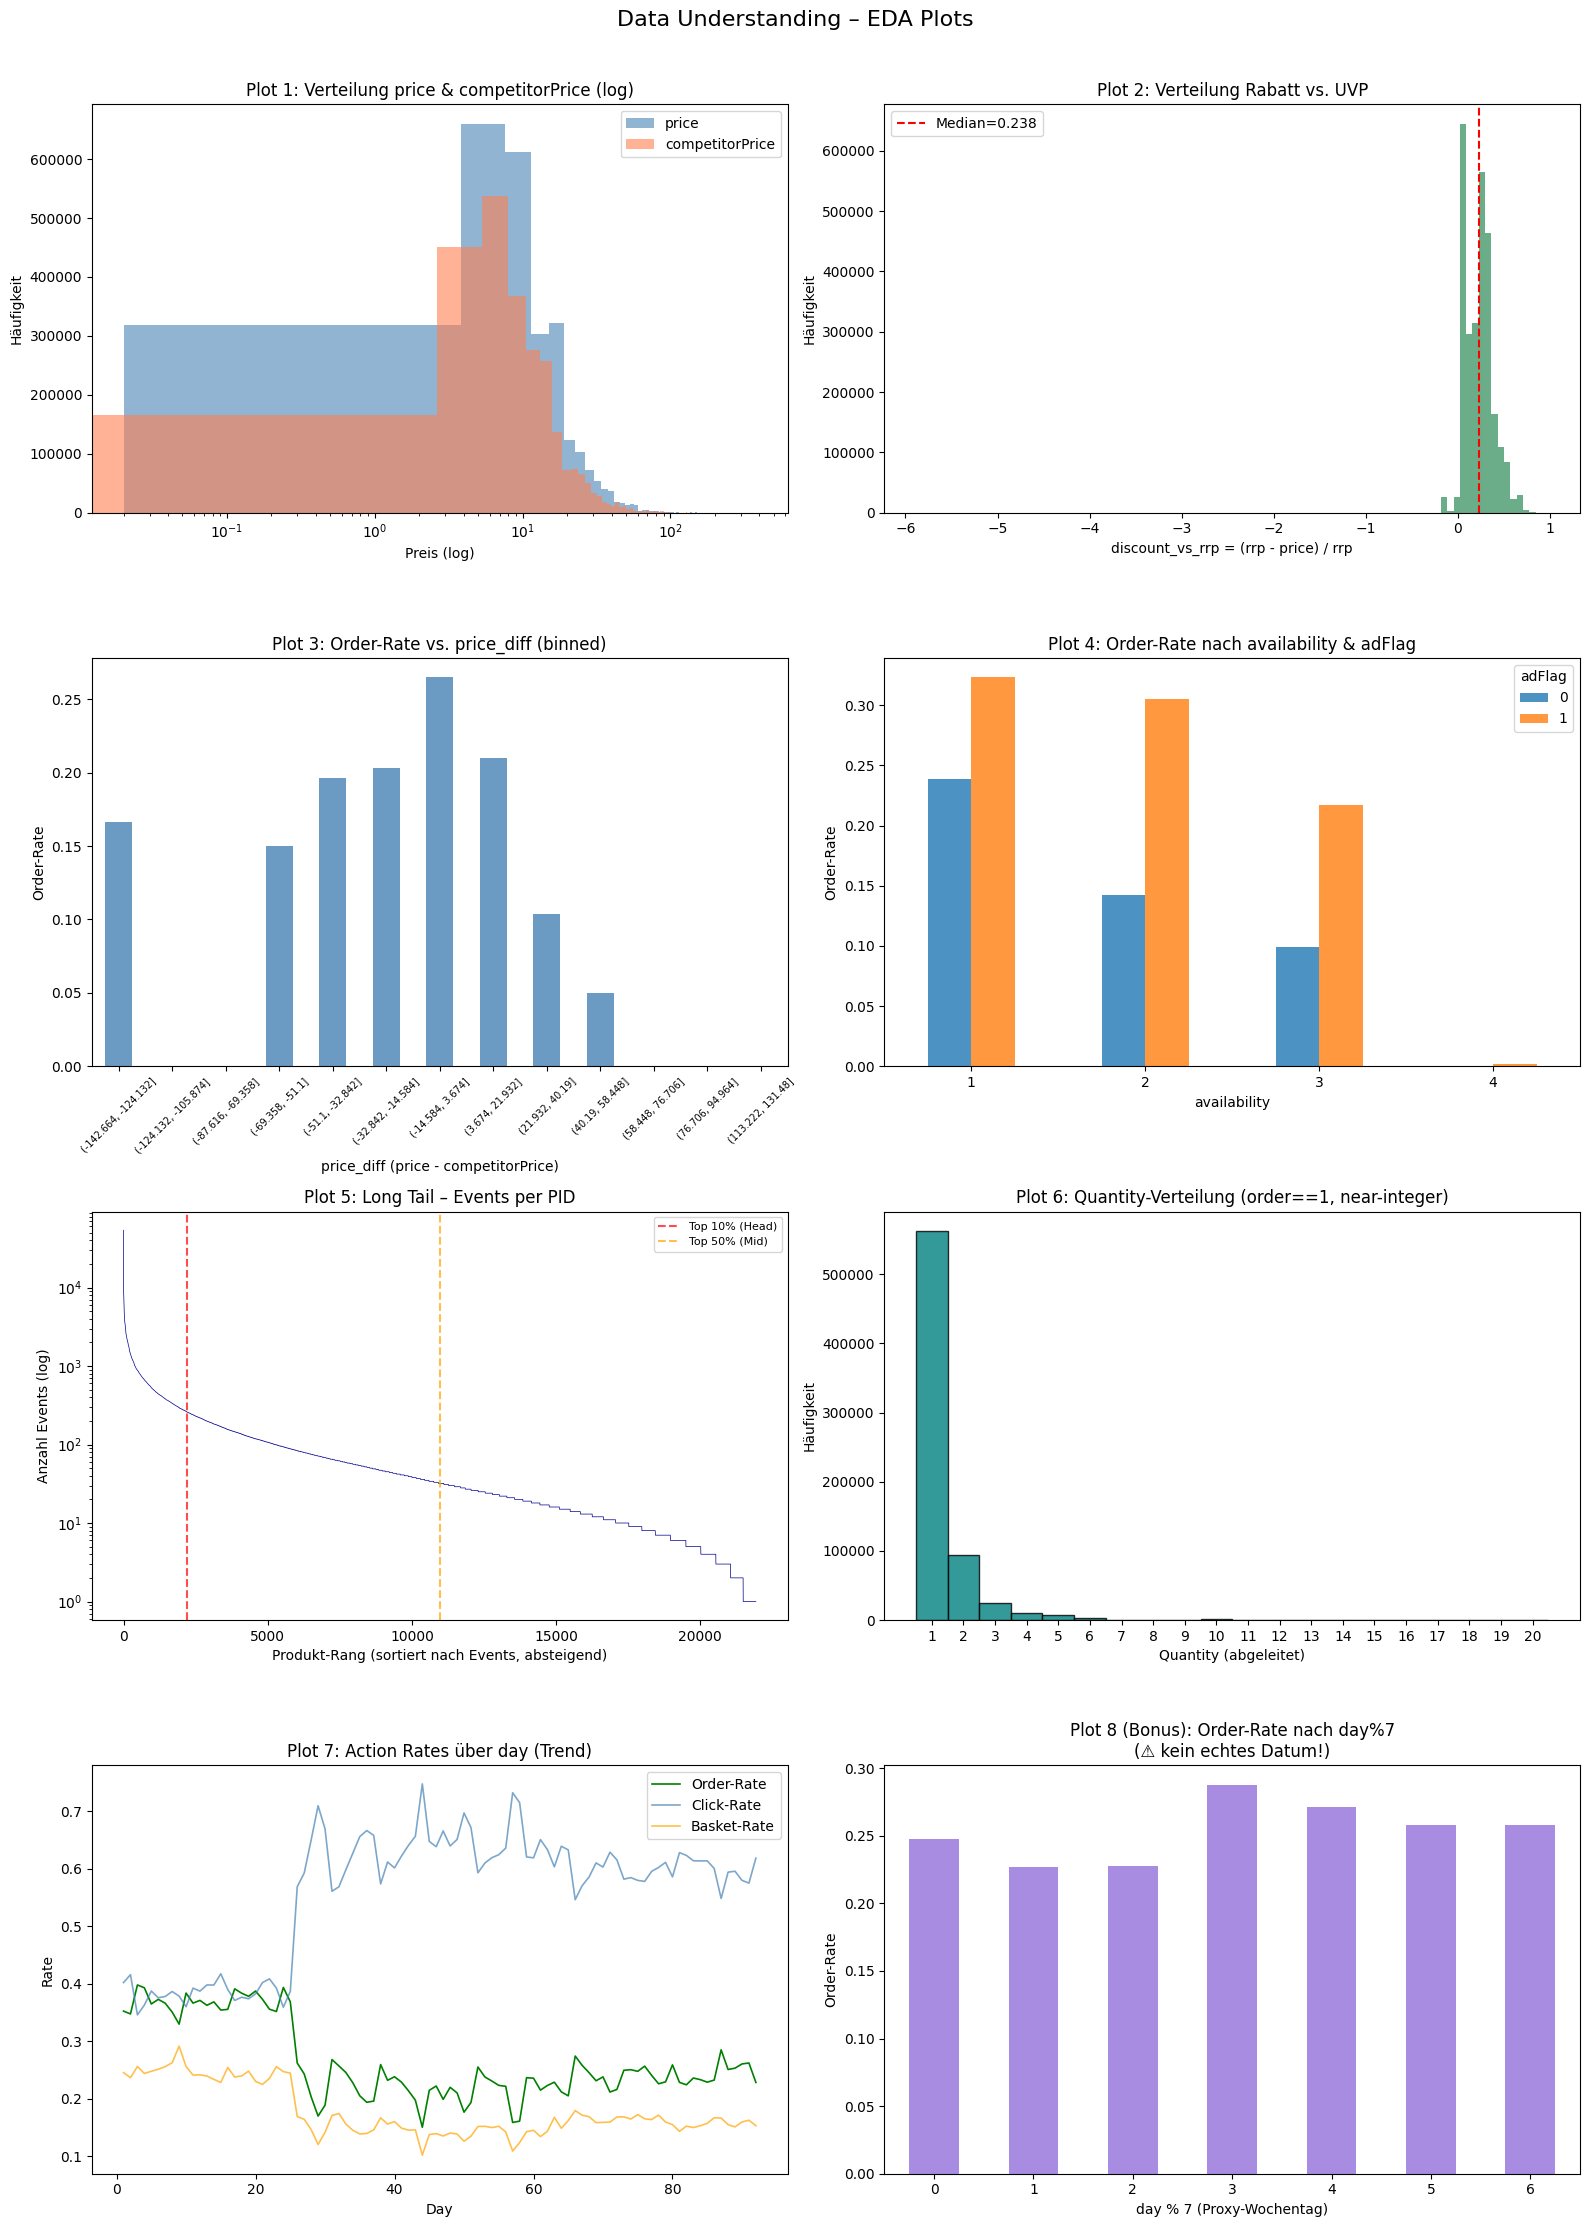

✓ Alle Plots erzeugt.


In [7]:
# =============================================================================
# 3.3) PLOTS – eda_plots()
# =============================================================================
def eda_plots(df_eda, events_per_pid, orders_valid, near_int_mask, day_stats):
    """Erzeugt mindestens 7 Plots für Data Understanding."""
    
    print("=" * 60)
    print("SECTION 3.3 – PLOTS")
    print("=" * 60)
    
    fig, axes = plt.subplots(4, 2, figsize=(16, 22))
    fig.suptitle("Data Understanding – EDA Plots", fontsize=16, y=1.01)
    
    # --- Plot 1: Distribution price & competitorPrice ---
    ax = axes[0, 0]
    ax.hist(df_eda["price"].dropna(), bins=100, alpha=0.6, label="price", color="steelblue")
    ax.hist(df_eda["competitorPrice"].dropna(), bins=100, alpha=0.6, 
            label="competitorPrice", color="coral")
    ax.set_xscale("log")
    ax.set_xlabel("Preis (log)")
    ax.set_ylabel("Häufigkeit")
    ax.set_title("Plot 1: Verteilung price & competitorPrice (log)")
    ax.legend()
    
    # --- Plot 2: Distribution discount_vs_rrp ---
    ax = axes[0, 1]
    disc = df_eda["discount_vs_rrp"].dropna()
    ax.hist(disc, bins=100, alpha=0.7, color="seagreen")
    ax.axvline(disc.median(), color="red", linestyle="--", label=f"Median={disc.median():.3f}")
    ax.set_xlabel("discount_vs_rrp = (rrp - price) / rrp")
    ax.set_ylabel("Häufigkeit")
    ax.set_title("Plot 2: Verteilung Rabatt vs. UVP")
    ax.legend()
    
    # --- Plot 3: Order-Rate vs. binned price_diff ---
    ax = axes[1, 0]
    comp_df = df_eda[df_eda["price_diff"].notna()].copy()
    comp_df["price_diff_bin"] = pd.cut(comp_df["price_diff"], bins=15)
    order_by_diff = comp_df.groupby("price_diff_bin", observed=True)["order"].mean()
    order_by_diff.plot(kind="bar", ax=ax, color="steelblue", alpha=0.8)
    ax.set_xlabel("price_diff (price - competitorPrice)")
    ax.set_ylabel("Order-Rate")
    ax.set_title("Plot 3: Order-Rate vs. price_diff (binned)")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    
    # --- Plot 4: Order-Rate by availability & adFlag ---
    ax = axes[1, 1]
    pivot = df_eda.groupby(["availability", "adFlag"])["order"].mean().unstack()
    pivot.plot(kind="bar", ax=ax, alpha=0.8)
    ax.set_xlabel("availability")
    ax.set_ylabel("Order-Rate")
    ax.set_title("Plot 4: Order-Rate nach availability & adFlag")
    ax.legend(title="adFlag")
    ax.tick_params(axis="x", rotation=0)
    
    # --- Plot 5: Long-Tail – events per PID ---
    ax = axes[2, 0]
    ax.plot(range(len(events_per_pid)), events_per_pid.values, color="darkblue", linewidth=0.5)
    ax.set_yscale("log")
    ax.set_xlabel("Produkt-Rang (sortiert nach Events, absteigend)")
    ax.set_ylabel("Anzahl Events (log)")
    ax.set_title("Plot 5: Long Tail – Events per PID")
    # Markiere Head/Mid/Tail
    n_pids = len(events_per_pid)
    ax.axvline(int(0.10 * n_pids), color="red", linestyle="--", alpha=0.7, label="Top 10% (Head)")
    ax.axvline(int(0.50 * n_pids), color="orange", linestyle="--", alpha=0.7, label="Top 50% (Mid)")
    ax.legend(fontsize=8)
    
    # --- Plot 6: Quantity distribution (order==1, near-integer) ---
    ax = axes[2, 1]
    quantities = orders_valid.loc[near_int_mask, "q_rounded"]
    q_max_plot = min(quantities.max(), 20)  # Cap bei 20 für Lesbarkeit
    ax.hist(quantities[quantities <= q_max_plot], 
            bins=np.arange(0.5, q_max_plot + 1.5, 1), alpha=0.8, color="teal", edgecolor="black")
    ax.set_xlabel("Quantity (abgeleitet)")
    ax.set_ylabel("Häufigkeit")
    ax.set_title("Plot 6: Quantity-Verteilung (order==1, near-integer)")
    ax.set_xticks(range(1, int(q_max_plot) + 1))
    
    # --- Plot 7: Order-Rate & Action Distribution über day ---
    ax = axes[3, 0]
    ax.plot(day_stats.index, day_stats["order_rate"], label="Order-Rate", color="green", linewidth=1.2)
    ax.plot(day_stats.index, day_stats["click_rate"], label="Click-Rate", color="steelblue", 
            linewidth=1.2, alpha=0.7)
    ax.plot(day_stats.index, day_stats["basket_rate"], label="Basket-Rate", color="orange", 
            linewidth=1.2, alpha=0.7)
    ax.set_xlabel("Day")
    ax.set_ylabel("Rate")
    ax.set_title("Plot 7: Action Rates über day (Trend)")
    ax.legend()
    
    # --- Plot 8 (Bonus): Order-Rate by day%7 ---
    ax = axes[3, 1]
    df_eda["day_mod7"] = df_eda["day"] % 7
    wd_order = df_eda.groupby("day_mod7")["order"].mean()
    wd_order.plot(kind="bar", ax=ax, color="mediumpurple", alpha=0.8)
    ax.set_xlabel("day % 7 (Proxy-Wochentag)")
    ax.set_ylabel("Order-Rate")
    ax.set_title("Plot 8 (Bonus): Order-Rate nach day%7\n(⚠ kein echtes Datum!)")
    ax.tick_params(axis="x", rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Alle Plots erzeugt.")

eda_plots(df_eda, events_per_pid, orders_valid, near_int_mask, day_stats)

In [10]:
# =============================================================================
# 4) VERIFY DATA QUALITY – summarize_quality()
# =============================================================================
def summarize_quality(train, items, df):
    """Dokumentiert Missing Values, High-Cardinality, Outliers, Bias, Time Split."""
    
    print("=" * 60)
    print("SECTION 4 – VERIFY DATA QUALITY")
    print("=" * 60)
    
    # --- 4.1 Missing Values ---
    print("\n--- 4.1 Missing Values (merged) mit Empfehlung ---")
    miss = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    
    recommendations = {
        "competitorPrice": "Imputation (Median pro PID/Gruppe) + Missing-Flag; Missingness ist informativ",
        "category":        "Missing als eigene Kategorie 'NONE'; strukturelles Missing",
        "campaignIndex":   "Missing als eigene Kategorie 'NONE'; nur Kampagnenprodukte haben Label",
        "rrp":             "Imputation falls wenig missing; sonst Missing-Flag; benötigt für discount_vs_rrp",
        "manufacturer":    "Prüfen ob NaN; falls ja: Missing-Flag",
        "group":           "Prüfen ob NaN; falls ja: Missing-Flag oder 'UNKNOWN'",
        "content":         "Prüfen ob NaN; falls ja: Missing-Flag",
        "unit":            "Prüfen ob NaN; falls ja: Missing-Flag",
        "pharmForm":       "Prüfen ob NaN; falls ja: Missing-Flag",
    }
    
    found_missing = False
    for col in df.columns:
        if miss[col] > 0:
            found_missing = True
            rec = recommendations.get(col, "Einzeln bewerten")
            print(f"  {col}: {miss[col]:,} missing ({miss_pct[col]:.2f}%) -> {rec}")
    
    if not found_missing:
        print("  Keine Missing Values gefunden.")
    
    # --- 4.2 High-Cardinality Features ---
    print("\n--- 4.2 High-Cardinality / Noisy Features ---")
    for col in ["manufacturer", "group", "content", "pharmForm", "category"]:
        if col in df.columns:
            n_unique = df[col].nunique()
            flag = "!! high cardinality" if n_unique > 50 else "ok"
            print(f"  {col}: {n_unique:,} unique values -> {flag}")
    
    # pharmForm Inkonsistenz-Check
    if "pharmForm" in df.columns:
        pf_raw = df["pharmForm"].dropna().unique()
        pf_upper = df["pharmForm"].dropna().str.upper().str.strip().unique()
        if len(pf_raw) != len(pf_upper):
            print(f"  !! pharmForm Schreibweise-Inkonsistenz: {len(pf_raw)} raw vs {len(pf_upper)} nach upper()")
        else:
            print(f"  OK pharmForm: keine Inkonsistenz ({len(pf_raw)} == {len(pf_upper)})")
    
    # content Multipack-Check
    if "content" in df.columns:
        content_str = df["content"].astype(str)
        is_multipack = content_str.str.contains(r"\d+[Xx]\d+", na=False)
        print(f"  content: {is_multipack.sum():,} Zeilen mit Multipack-Muster (z.B. '10X1')")
        print(f"    -> {is_multipack.mean()*100:.2f}% aller Zeilen")
    
    # --- 4.3 Outliers & Invalid Values ---
    print("\n--- 4.3 Outliers & Invalid Values ---")
    
    n_price_le0 = (df["price"] <= 0).sum()
    print(f"  price <= 0: {n_price_le0:,} Zeilen")
    
    cp = df["competitorPrice"].dropna()
    q1_val, q3_val = cp.quantile(0.25), cp.quantile(0.75)
    iqr_val = q3_val - q1_val
    lower_b, upper_b = q1_val - 3 * iqr_val, q3_val + 3 * iqr_val
    n_cp_outliers = ((cp < lower_b) | (cp > upper_b)).sum()
    print(f"  competitorPrice extreme (3xIQR): {n_cp_outliers:,} Zeilen")
    print(f"    IQR=[{q1_val:.2f}, {q3_val:.2f}], Bounds=[{lower_b:.2f}, {upper_b:.2f}]")
    
    if "rrp" in df.columns:
        rrp_col = df["rrp"].dropna()
        n_rrp_le0 = (rrp_col <= 0).sum()
        n_rrp_lt_price = (df["rrp"] < df["price"]).sum()
        print(f"  rrp <= 0: {n_rrp_le0:,} Zeilen")
        print(f"  rrp < price (neg. Rabatt): {n_rrp_lt_price:,} ({n_rrp_lt_price/len(df)*100:.2f}%)")
    
    n_rev_neg = (df["revenue"] < 0).sum()
    print(f"  revenue < 0: {n_rev_neg:,} Zeilen")
    
    # --- 4.4 Long-Tail Bias ---
    print("\n--- 4.4 Dataset Bias / Long-Tail ---")
    epp = df.groupby("pid")["lineID"].count().sort_values(ascending=False)
    n_pids = len(epp)
    n_head = int(0.10 * n_pids)
    n_mid_end = int(0.50 * n_pids)
    
    head_ev = epp.iloc[:n_head].sum()
    mid_ev = epp.iloc[n_head:n_mid_end].sum()
    tail_ev = epp.iloc[n_mid_end:].sum()
    total = len(df)
    
    print(f"  Head (Top 10%, n={n_head}): {head_ev:,} Events ({head_ev/total*100:.2f}%)")
    print(f"  Mid  (10-50%, n={n_mid_end-n_head}): {mid_ev:,} Events ({mid_ev/total*100:.2f}%)")
    print(f"  Tail (Bot 50%, n={n_pids-n_mid_end}): {tail_ev:,} Events ({tail_ev/total*100:.2f}%)")
    
    print("\n  !! Risiko: Ungewichtete Metriken spiegeln primär Head-Produkte.")
    print("  -> Stratifizierte Evaluation pro Band (Head/Mid/Tail)")
    
    head_pids = set(epp.iloc[:n_head].index)
    mid_pids = set(epp.iloc[n_head:n_mid_end].index)
    tail_pids = set(epp.iloc[n_mid_end:].index)
    
    for name, pids in [("Head", head_pids), ("Mid", mid_pids), ("Tail", tail_pids)]:
        sub = df[df["pid"].isin(pids)]
        print(f"  Order-Rate {name}: {sub['order'].mean():.4f}")
    
    # --- 4.5 Time Split ---
    print("\n--- 4.5 Time Leakage / Split Design ---")
    print("  Primär: TEMPORAL GENERALIZATION")
    print("    -> Time Split testet echte Generalisierung auf zukünftige Tage.")
    print("  Sekundär: Hard Leakage bei Lag Features")
    print("    -> Random Split würde zukünftige Werte in Vergangenheit leaken.")
    
    for name, d_min, d_max in [("Train", 1, 70), ("Val", 71, 81), ("Test", 82, 92)]:
        n = ((df["day"] >= d_min) & (df["day"] <= d_max)).sum()
        print(f"  {name} (day {d_min}-{d_max}): {n:,} Zeilen ({n/len(df)*100:.1f}%)")
    
    print(f"\n{'='*60}")
    print("DATA QUALITY SUMMARY COMPLETE")
    print(f"{'='*60}")

summarize_quality(train, items, df)

SECTION 4 – VERIFY DATA QUALITY

--- 4.1 Missing Values (merged) mit Empfehlung ---
  competitorPrice: 100,687 missing (3.65%) -> Imputation (Median pro PID/Gruppe) + Missing-Flag; Missingness ist informativ
  pharmForm: 194,124 missing (7.04%) -> Prüfen ob NaN; falls ja: Missing-Flag
  category: 87,394 missing (3.17%) -> Missing als eigene Kategorie 'NONE'; strukturelles Missing
  campaignIndex: 2,287,968 missing (83.02%) -> Missing als eigene Kategorie 'NONE'; nur Kampagnenprodukte haben Label

--- 4.2 High-Cardinality / Noisy Features ---
  manufacturer: 1,065 unique values -> !! high cardinality
  group: 533 unique values -> !! high cardinality
  content: 548 unique values -> !! high cardinality
  pharmForm: 278 unique values -> !! high cardinality
  category: 409 unique values -> !! high cardinality
  !! pharmForm Schreibweise-Inkonsistenz: 278 raw vs 183 nach upper()
  content: 153,875 Zeilen mit Multipack-Muster (z.B. '10X1')
    -> 5.58% aller Zeilen

--- 4.3 Outliers & Invalid

In [9]:
# =============================================================================
# 5) OUTPUTS FOR NEXT PHASE – Summary & To-Do
# =============================================================================
print("=" * 60)
print("SECTION 5 – OUTPUTS FOR DATA PREPARATION")
print("=" * 60)

print("""
To-Do Liste für Data Preparation:
──────────────────────────────────
 1. Left-Join train + items auf pid
    → Assert: 0 orphan train PIDs; dokumentiere orphan items count

 2. Normalize pharmForm
    → .str.upper().str.strip()

 3. Quantity ableiten
    → quantity = round(revenue / price) für order==1
    → Nur wenn |q_raw - round(q_raw)| <= 0.01; sonst NaN

 4. Leakage-Spalten droppen
    → revenue, q_raw entfernen

 5. Feature Engineering
    → price_diff = price - competitorPrice
    → price_ratio = price / competitorPrice
    → discount_vs_rrp = (rrp - price) / rrp
    → comp_missing_flag = 1 wenn competitorPrice NaN

 6. Content parsen
    → Regex \\d+X\\d+ → is_multipack, pack_n, pack_size

 7. Encoding (in Data Preparation entscheiden)
    → availability: Ordinal vs. One-Hot testen
    → salesIndex: One-Hot (4 Werte)
    → campaignIndex: NA → 'NONE', One-Hot
    → manufacturer: Frequency-/Target-Encoding oder Top-N OHE
    → group: Top-N oder Embedding
    → category: One-Hot mit Null-Kategorie

 8. Wochentag-Proxy
    → day_mod7 = day % 7 (⚠ kein echtes Datum!)

 9. Time-Based Split
    → Train: day 1-70, Val: day 71-81, Test: day 82-92

10. Baseline-Modell
    → Logistic Regression auf price_diff, discount_vs_rrp,
      adFlag, availability, genericProduct → Benchmark AUC
""")

print("=" * 60)
print("DATA UNDERSTANDING COMPLETE")
print("=" * 60)

SECTION 5 – OUTPUTS FOR DATA PREPARATION

To-Do Liste für Data Preparation:
──────────────────────────────────
 1. Left-Join train + items auf pid
    → Assert: 0 orphan train PIDs; dokumentiere orphan items count

 2. Normalize pharmForm
    → .str.upper().str.strip()

 3. Quantity ableiten
    → quantity = round(revenue / price) für order==1
    → Nur wenn |q_raw - round(q_raw)| <= 0.01; sonst NaN

 4. Leakage-Spalten droppen
    → revenue, q_raw entfernen

 5. Feature Engineering
    → price_diff = price - competitorPrice
    → price_ratio = price / competitorPrice
    → discount_vs_rrp = (rrp - price) / rrp
    → comp_missing_flag = 1 wenn competitorPrice NaN

 6. Content parsen
    → Regex \d+X\d+ → is_multipack, pack_n, pack_size

 7. Encoding (in Data Preparation entscheiden)
    → availability: Ordinal vs. One-Hot testen
    → salesIndex: One-Hot (4 Werte)
    → campaignIndex: NA → 'NONE', One-Hot
    → manufacturer: Frequency-/Target-Encoding oder Top-N OHE
    → group: Top-N 